# Gaussian Mixture Model (GMM)

Gaussian Mixture Model (GMM) is an unsupervised learning algorithm used for clustering.

Unlike K-Means, which assigns each observation to exactly one cluster, GMM uses probability distributions to determine how likely an observation is to belong to each cluster.

GMM assumes that the data is generated from a mixture of several Gaussian (normal) distributions.

### Example

Suppose we have three groups:

```text
        Gaussian 1
       /          \
      /            \

               Gaussian 2
              /          \

                         Gaussian 3

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = sns.load_dataset("penguins")

df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
df.shape

(344, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [5]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

X = df[features].dropna()

X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.88449874,  0.78544923, -1.41834665, -0.56414208],
       [-0.81112573,  0.1261879 , -1.06225022, -0.50170305],
       [-0.66437972,  0.43046236, -0.42127665, -1.18853234],
       [-1.32473679,  1.08972369, -0.56371522, -0.93877623],
       [-0.84781224,  1.74898502, -0.77737308, -0.68902013]])

In [9]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

gmm.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None


In [10]:
labels = gmm.predict(X_scaled)

labels[:20]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [11]:
result = X.copy()

result["Cluster"] = labels

result.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Cluster
0,39.1,18.7,181.0,3750.0,2
1,39.5,17.4,186.0,3800.0,2
2,40.3,18.0,195.0,3250.0,2
4,36.7,19.3,193.0,3450.0,2
5,39.3,20.6,190.0,3650.0,2


In [12]:
result["Cluster"].value_counts().sort_index()

Cluster
0     67
1    123
2    152
Name: count, dtype: int64

In [13]:
probabilities = gmm.predict_proba(
    X_scaled
)

probabilities[:5]

array([[5.23507968e-06, 6.37645875e-36, 9.99994765e-01],
       [9.87629525e-04, 2.65163566e-22, 9.99012370e-01],
       [3.47677933e-02, 7.28965104e-23, 9.65232207e-01],
       [1.56501879e-06, 1.22042185e-34, 9.99998435e-01],
       [2.71246065e-07, 3.17909070e-45, 9.99999729e-01]])

In [14]:
probability_df = pd.DataFrame(
    probabilities,
    columns=[
        "Cluster_0_Probability",
        "Cluster_1_Probability",
        "Cluster_2_Probability"
    ]
)

probability_df.head()

,Cluster_0_Probability,Cluster_1_Probability,Cluster_2_Probability
0,5.235080e-06,6.376459e-36,0.999995
1,9.876295e-04,2.651636e-22,0.999012
2,3.476779e-02,7.289651e-23,0.965232
3,1.565019e-06,1.220422e-34,0.999998
4,2.712461e-07,3.179091e-45,1.000000


In [15]:
probability_df.sum(axis=1).head()

0    1.0
1    1.0
2    1.0
3    1.0
4    1.0
dtype: float64

In [16]:
result_with_probabilities = pd.concat(
    [
        result.reset_index(drop=True),
        probability_df
    ],
    axis=1
)

result_with_probabilities.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,Cluster,Cluster_0_Probability,Cluster_1_Probability,Cluster_2_Probability
0,39.1,18.7,181.0,3750.0,2,5.235080e-06,6.376459e-36,0.999995
1,39.5,17.4,186.0,3800.0,2,9.876295e-04,2.651636e-22,0.999012
2,40.3,18.0,195.0,3250.0,2,3.476779e-02,7.289651e-23,0.965232
3,36.7,19.3,193.0,3450.0,2,1.565019e-06,1.220422e-34,0.999998
4,39.3,20.6,190.0,3650.0,2,2.712461e-07,3.179091e-45,1.000000


In [17]:
cluster_summary = result.groupby(
    "Cluster"
)[features].mean()

cluster_summary

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
Cluster,,,,
0,49.026866,18.482090,196.537313,3758.955224
1,47.504878,14.982114,217.186992,5076.016260
2,38.772368,18.319737,189.677632,3689.473684


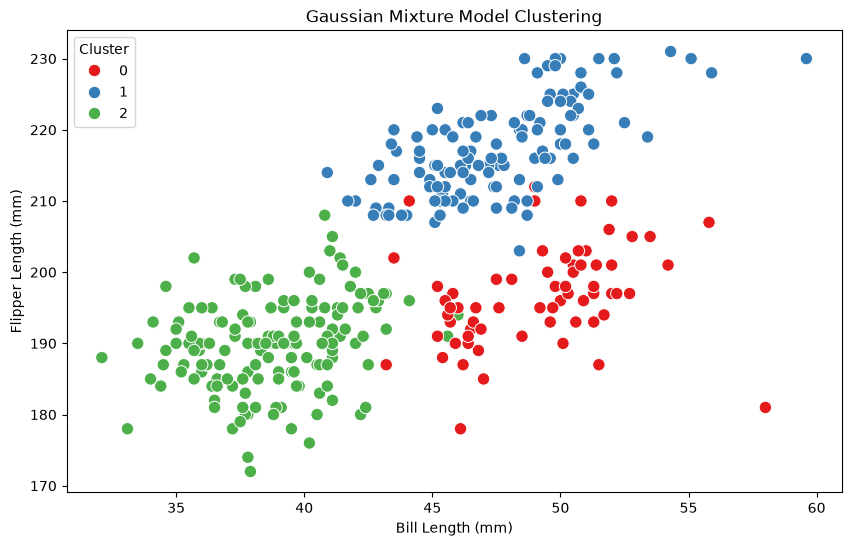

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=result,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="Cluster",
    palette="Set1",
    s=80
)

plt.title(
    "Gaussian Mixture Model Clustering"
)

plt.xlabel(
    "Bill Length (mm)"
)

plt.ylabel(
    "Flipper Length (mm)"
)

plt.show()